In [21]:
import time
import random
import requests
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['figure.figsize'] = (8, 4)

APP_IDS = [570, 730, 271590]  # dota2, cs2, gta v
LANGUAGE = "all"
FILTER = "recent"
REVIEWS_PER_PAGE = 100
TOTAL_MAX_REVIEWS = 3000
MAX_REVIEWS_PER_APP = 1000
REQUEST_TIMEOUT = 10
SLEEP_BETWEEN = (0.3, 0.8)

MAX_FEATURES = 50000
NGRAM_RANGE = (1, 2)
TEST_SIZE = 0.2
SEED = 42

LOGREG_PARAMS = {
    'solver': 'liblinear',
    'max_iter': 300,
    'class_weight': 'balanced',
    'n_jobs': 1,
    'random_state': SEED,
}

random.seed(SEED)


In [22]:
session = requests.Session()
session.headers.update({
    "user-agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0 Safari/537.36",
    "accept": "application/json, text/plain, */*",
})


def fetch_reviews(app_id: int, max_reviews: int, language: str, filt: str, per_page: int):
    cursor = "*"
    reviews = []
    while len(reviews) < max_reviews:
        url = (
            f"https://store.steampowered.com/appreviews/{app_id}?json=1"
            f"&language={language}&purchase_type=all&filter={filt}"
            f"&num_per_page={per_page}&cursor={requests.utils.quote(cursor)}"
        )
        resp = session.get(url, timeout=REQUEST_TIMEOUT)
        if resp.status_code != 200:
            break
        data = resp.json()
        batch = data.get("reviews", [])
        if not batch:
            break
        for r in batch:
            reviews.append({
                "app_id": app_id,
                "review": r.get("review", ""),
                "voted_up": int(bool(r.get("voted_up", False))),
            })
        cursor = data.get("cursor", "")
        if not cursor:
            break
        time.sleep(random.uniform(*SLEEP_BETWEEN))
    return reviews[:max_reviews]


In [23]:
reviews = []
remaining = TOTAL_MAX_REVIEWS
for app_id in APP_IDS:
    need = min(remaining, MAX_REVIEWS_PER_APP)
    if need <= 0:
        break
    batch = fetch_reviews(app_id, need, language=LANGUAGE, filt=FILTER, per_page=REVIEWS_PER_PAGE)
    print(f"App {app_id}: {len(batch)} отзывов")
    reviews.extend(batch)
    remaining -= len(batch)
    if remaining <= 0:
        break

df = pd.DataFrame(reviews)
print(f"Всего отзывов: {len(df)}")
print(df['voted_up'].value_counts())


App 570: 1000 отзывов
App 730: 1000 отзывов
App 271590: 1000 отзывов
Всего отзывов: 3000
voted_up
1    2462
0     538
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['voted_up'], test_size=TEST_SIZE, random_state=SEED, stratify=df['voted_up']
)

vectorizer = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, lowercase=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(X_train_vec.shape, X_test_vec.shape)


(2400, 18771) (600, 18771)


In [25]:
logreg = LogisticRegression(**LOGREG_PARAMS)
logreg.fit(X_train_vec, y_train)

train_pred = logreg.predict(X_train_vec)
test_pred = logreg.predict(X_test_vec)

print("Train acc/F1:", accuracy_score(y_train, train_pred), f1_score(y_train, train_pred))
print("Test acc/F1:", accuracy_score(y_test, test_pred), f1_score(y_test, test_pred))


Train acc/F1: 0.9529166666666666 0.9707783811740367
Test acc/F1: 0.795 0.8735868448098664


              precision    recall  f1-score   support

           0      0.437     0.481     0.458       108
           1      0.884     0.864     0.874       492

    accuracy                          0.795       600
   macro avg      0.660     0.673     0.666       600
weighted avg      0.803     0.795     0.799       600



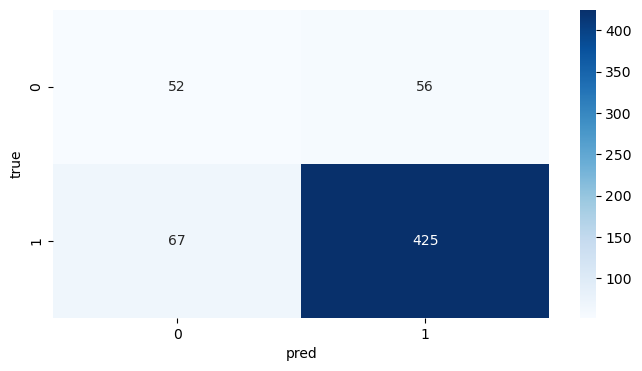

Топ 20 признаков по модулю веса:
не: -3.4269
good: 2.5076
хуета: -2.4163
залупа: -2.0022
хуйня: -1.9247
нет: -1.8803
говно: -1.8375
имба: 1.8181
помойка: -1.6720
govno: -1.6500
калл: -1.5468
cheaters: -1.5428
круто: 1.4495
игра говно: -1.4152
bom: 1.4121
фу: -1.3965
норм: 1.3937
габена: -1.3866
no: -1.3465
топ: 1.3350


In [26]:
print(classification_report(y_test, test_pred, digits=3))

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("pred"); plt.ylabel("true"); plt.show()

import numpy as np
coefs = logreg.coef_[0]
vocab = vectorizer.get_feature_names_out()
idx = np.argsort(np.abs(coefs))[::-1][:20]
print("Топ 20 признаков по модулю веса:")
for i in idx:
    print(f"{vocab[i]}: {coefs[i]:.4f}")
